# 🧬 Colorectal Cancer Risk & Survival Prediction

## 🎯 Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## 📋 Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## 🗺️ Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# 📦 Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:

# 📂 Load the dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')

# Display basic information about the dataset
print("Shape:", df.shape)
df.info()
df.head()


Shape: (89945, 30)
<class 'pandas.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  str    
 3   Race                     89945 non-null  str    
 4   Region                   89945 non-null  str    
 5   Urban_or_Rural           89945 non-null  str    
 6   Socioeconomic_Status     89945 non-null  str    
 7   Family_History           89945 non-null  str    
 8   Previous_Cancer_History  89945 non-null  str    
 9   Stage_at_Diagnosis       89945 non-null  str    
 10  Tumor_Aggressiveness     89945 non-null  str    
 11  Colonoscopy_Access       89945 non-null  str    
 12  Screening_Regularity     89945 non-null  str    
 13  Diet_Type                89945 non-null  str    
 14  BMI           

,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


## 🔍 Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [3]:

# ✅ Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:


Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64



Total missing values: 0


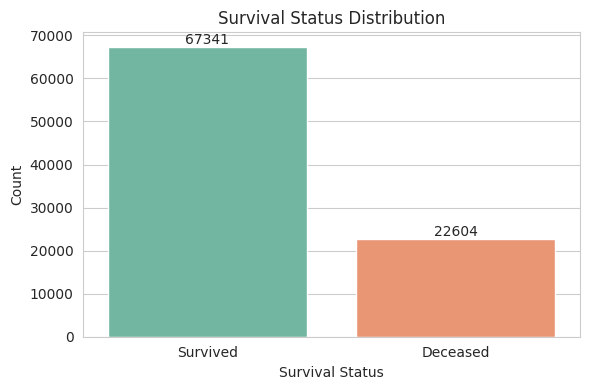

Survival_Status
Survived    74.869087
Deceased    25.130913
Name: proportion, dtype: float64


In [4]:

# 📊 Visualize survival status distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Survival_Status', hue='Survival_Status', palette='Set2', legend=False)
plt.title('Survival Status Distribution')
plt.xlabel('Survival Status')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['Survival_Status'].value_counts(normalize=True) * 100)


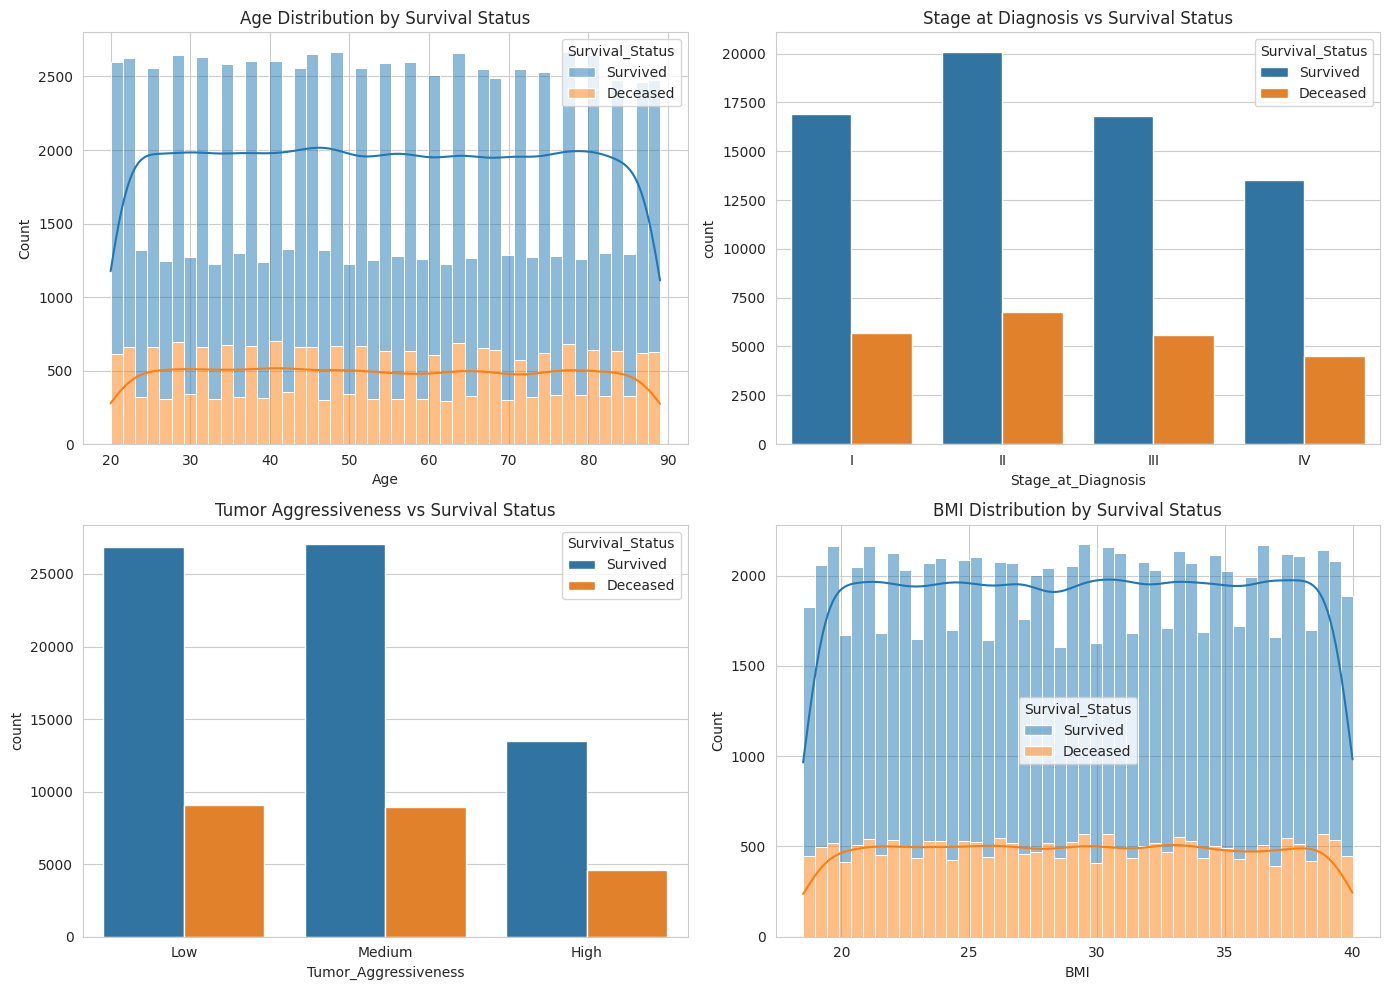

In [5]:

# 📈 Distribution of key numerical/categorical features against survival status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='Age', hue='Survival_Status', kde=True, ax=axes[0, 0], multiple='stack')
axes[0, 0].set_title('Age Distribution by Survival Status')

sns.countplot(data=df, x='Stage_at_Diagnosis', hue='Survival_Status',
              order=['I', 'II', 'III', 'IV'], ax=axes[0, 1])
axes[0, 1].set_title('Stage at Diagnosis vs Survival Status')

sns.countplot(data=df, x='Tumor_Aggressiveness', hue='Survival_Status',
              order=['Low', 'Medium', 'High'], ax=axes[1, 0])
axes[1, 0].set_title('Tumor Aggressiveness vs Survival Status')

sns.histplot(data=df, x='BMI', hue='Survival_Status', kde=True, ax=axes[1, 1], multiple='stack')
axes[1, 1].set_title('BMI Distribution by Survival Status')

plt.tight_layout()
plt.show()


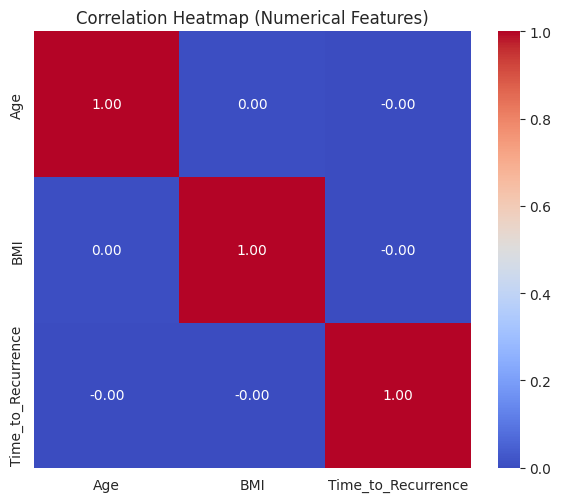

In [6]:

# 🌡️ Correlation heatmap (numerical features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Patient_ID')
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()


## 🧮 Survival Rate by Key Groups
Rather than raw counts, let's look at the **survival rate (%)** within each category — this tells us whether a group is disproportionately more or less likely to survive.

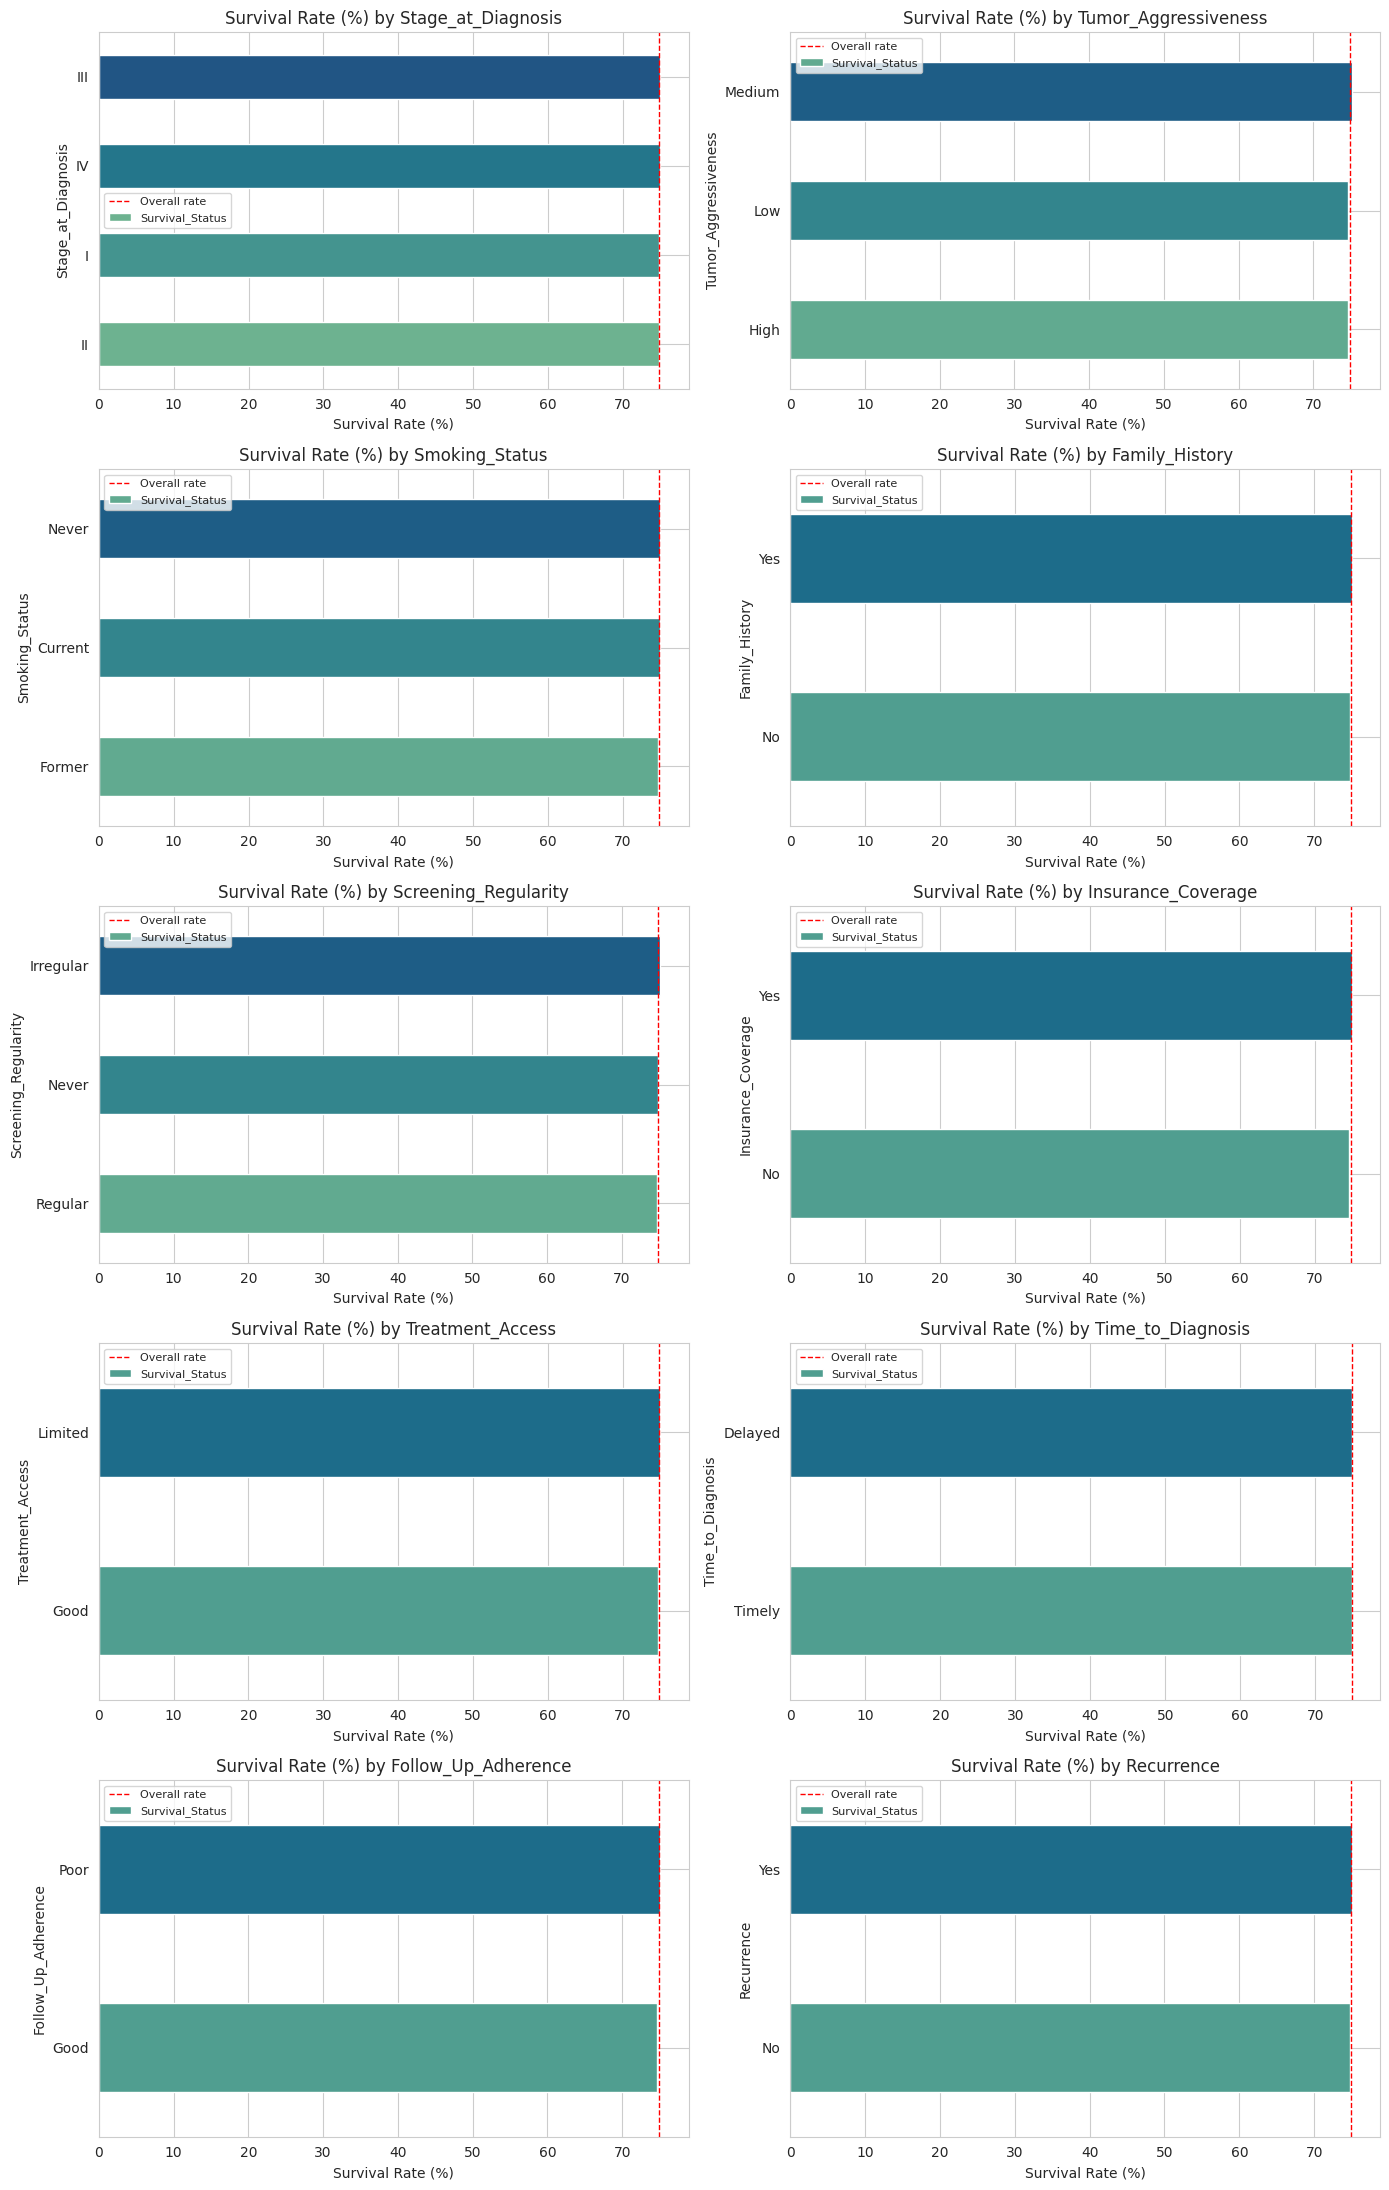

In [7]:

# 🧮 Survival rate (%) across several clinically relevant groupings
group_cols = ['Stage_at_Diagnosis', 'Tumor_Aggressiveness', 'Smoking_Status',
              'Family_History', 'Screening_Regularity', 'Insurance_Coverage',
              'Treatment_Access', 'Time_to_Diagnosis', 'Follow_Up_Adherence', 'Recurrence']

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(group_cols):
    survival_rate = (df.groupby(col)['Survival_Status']
                        .apply(lambda x: (x == 'Survived').mean() * 100)
                        .sort_values())
    survival_rate.plot(kind='barh', ax=axes[i], color=sns.color_palette('crest', len(survival_rate)))
    axes[i].set_title(f'Survival Rate (%) by {col}')
    axes[i].set_xlabel('Survival Rate (%)')
    axes[i].axvline(df['Survival_Status'].eq('Survived').mean() * 100,
                     color='red', linestyle='--', linewidth=1, label='Overall rate')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 🧪 Statistical Hypothesis Testing
Visual differences can be misleading with a large sample — let's formally test whether each feature is **statistically associated** with `Survival_Status`.
- **Categorical features** → Chi-Square test of independence
- **Numerical features** → Independent-samples t-test (Survived vs Deceased)

A p-value below 0.05 suggests a statistically significant association.

In [8]:

# 🧪 Chi-Square test for categorical features vs Survival_Status
categorical_features = ['Gender', 'Race', 'Region', 'Urban_or_Rural', 'Socioeconomic_Status',
                         'Family_History', 'Previous_Cancer_History', 'Stage_at_Diagnosis',
                         'Tumor_Aggressiveness', 'Colonoscopy_Access', 'Screening_Regularity',
                         'Diet_Type', 'Physical_Activity_Level', 'Smoking_Status',
                         'Alcohol_Consumption', 'Red_Meat_Consumption', 'Fiber_Consumption',
                         'Insurance_Coverage', 'Time_to_Diagnosis', 'Treatment_Access',
                         'Chemotherapy_Received', 'Radiotherapy_Received', 'Surgery_Received',
                         'Follow_Up_Adherence', 'Recurrence']

chi2_results = []
for col in categorical_features:
    contingency = pd.crosstab(df[col], df['Survival_Status'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({'Feature': col, 'Chi2': chi2, 'p_value': p,
                          'Significant (p<0.05)': '✅ Yes' if p < 0.05 else '❌ No'})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df


,Feature,Chi2,p_value,Significant (p<0.05)
21,Radiotherapy_Received,4.041520,0.044394,✅ Yes
22,Surgery_Received,3.012862,0.082606,❌ No
0,Gender,2.404597,0.120979,❌ No
2,Region,7.276147,0.121995,❌ No
23,Follow_Up_Adherence,1.759323,0.184709,❌ No
11,Diet_Type,2.935390,0.230456,❌ No
8,Tumor_Aggressiveness,2.702277,0.258945,❌ No
4,Socioeconomic_Status,2.590489,0.273831,❌ No
1,Race,5.012524,0.286015,❌ No
15,Red_Meat_Consumption,2.404967,0.300447,❌ No


In [9]:

# 🧪 T-test for numerical features vs Survival_Status
numerical_features = ['Age', 'BMI', 'Time_to_Recurrence']

ttest_results = []
for col in numerical_features:
    survived = df.loc[df['Survival_Status'] == 'Survived', col]
    deceased = df.loc[df['Survival_Status'] == 'Deceased', col]
    t_stat, p_val = stats.ttest_ind(survived, deceased, equal_var=False)
    ttest_results.append({'Feature': col, 't_stat': t_stat, 'p_value': p_val,
                          'Significant (p<0.05)': '✅ Yes' if p_val < 0.05 else '❌ No'})

ttest_df = pd.DataFrame(ttest_results)
ttest_df


,Feature,t_stat,p_value,Significant (p<0.05)
0,Age,0.752357,0.451841,❌ No
1,BMI,0.784439,0.432788,❌ No
2,Time_to_Recurrence,0.623410,0.533019,❌ No


## 🔁 Recurrence vs Survival
Cancer recurrence is often clinically linked to survival outcomes — let's check that relationship specifically.

Survival_Status  Deceased  Survived
Recurrence                         
No               25.20524  74.79476
Yes              24.95736  75.04264


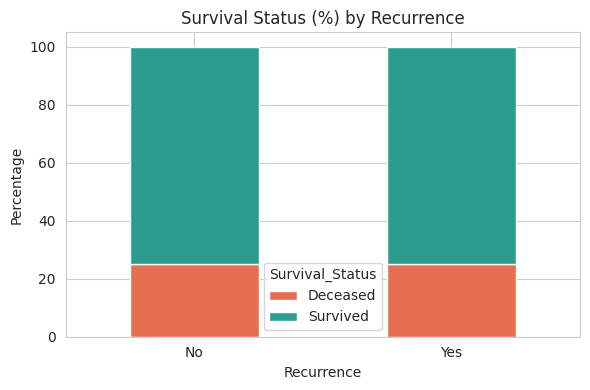

In [10]:

# 🔁 Recurrence vs Survival cross-tab and chart
recurrence_ct = pd.crosstab(df['Recurrence'], df['Survival_Status'], normalize='index') * 100
print(recurrence_ct)

recurrence_ct.plot(kind='bar', stacked=True, figsize=(6, 4), color=['#e76f51', '#2a9d8f'])
plt.title('Survival Status (%) by Recurrence')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 🛠️ Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [11]:

# 🗑️ Drop unnecessary columns (e.g., Patient ID if present)
df_model = df.drop(columns=['Patient_ID'])

# No missing values were found in the EDA step, so no imputation is required.
# If missing values existed, we would handle them here, e.g.:
# df_model[numeric_col] = df_model[numeric_col].fillna(df_model[numeric_col].median())
# df_model[categorical_col] = df_model[categorical_col].fillna(df_model[categorical_col].mode()[0])

df_model.isnull().sum().sum()


np.int64(0)

In [12]:

# 🏷️ Encode categorical variables
# Binary Yes/No style columns -> LabelEncoder (0/1)
binary_cols = ['Family_History', 'Previous_Cancer_History', 'Colonoscopy_Access',
               'Insurance_Coverage', 'Chemotherapy_Received', 'Radiotherapy_Received',
               'Surgery_Received', 'Recurrence', 'Gender', 'Urban_or_Rural',
               'Time_to_Diagnosis', 'Treatment_Access', 'Follow_Up_Adherence']

label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Target variable
target_le = LabelEncoder()
df_model['Survival_Status'] = target_le.fit_transform(df_model['Survival_Status'])
# Check mapping: which class is 1
print("Survival_Status classes:", dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

# Ordinal categorical columns -> mapped in meaningful order
ordinal_maps = {
    'Stage_at_Diagnosis': {'I': 0, 'II': 1, 'III': 2, 'IV': 3},
    'Tumor_Aggressiveness': {'Low': 0, 'Medium': 1, 'High': 2},
    'Socioeconomic_Status': {'Low': 0, 'Middle': 1, 'High': 2},
    'Screening_Regularity': {'Never': 0, 'Irregular': 1, 'Regular': 2},
    'Physical_Activity_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Alcohol_Consumption': {'Low': 0, 'Medium': 1, 'High': 2},
    'Red_Meat_Consumption': {'Low': 0, 'Medium': 1, 'High': 2},
    'Fiber_Consumption': {'Low': 0, 'Medium': 1, 'High': 2},
    'Smoking_Status': {'Never': 0, 'Former': 1, 'Current': 2},
}
for col, mapping in ordinal_maps.items():
    df_model[col] = df_model[col].map(mapping)

# Nominal categorical columns (no inherent order) -> one-hot encode
nominal_cols = ['Race', 'Region', 'Diet_Type']
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

df_model.head()


Survival_Status classes: {'Deceased': np.int64(0), 'Survived': np.int64(1)}


,Age,Gender,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,Tumor_Aggressiveness,Colonoscopy_Access,Screening_Regularity,...,Race_Black,Race_Hispanic,Race_Other,Race_White,Region_Asia Pacific,Region_Europe,Region_Latin America,Region_North America,Diet_Type_Traditional,Diet_Type_Western
0,71,1,1,1,1,0,2,2,0,2,...,False,False,True,False,False,True,False,False,False,True
1,34,0,1,1,0,0,0,1,1,2,...,True,False,False,False,False,False,False,True,False,True
2,80,0,1,1,0,0,2,0,1,2,...,False,False,False,True,False,False,False,True,False,False
3,40,1,0,0,0,0,0,1,1,0,...,True,False,False,False,False,False,False,True,True,False
4,43,0,1,2,1,0,2,0,1,0,...,False,False,False,True,False,True,False,False,True,False


In [13]:

# 🎯 Define features and target variable
X = df_model.drop(columns=['Survival_Status'])
y = df_model['Survival_Status']  # Adjust target column name as needed

# Normalize numerical features
numeric_features = ['Age', 'BMI', 'Time_to_Recurrence']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (71956, 35)  Test shape: (17989, 35)


## 🧭 Feature Selection
Inspect which features are most associated with survival using correlation with the target (done here), and the trained models' coefficients / feature importances (done after model training below).

In [14]:

# 🧭 Quick look at correlation of each feature with the target
target_corr = X_scaled.assign(Survival_Status=y).corr()['Survival_Status'].drop('Survival_Status')
target_corr.sort_values(key=abs, ascending=False).head(15)


Region_North America    -0.008566
Radiotherapy_Received   -0.006729
Surgery_Received         0.005816
Diet_Type_Western       -0.005586
Race_Other               0.005479
Gender                   0.005196
Follow_Up_Adherence      0.004449
Region_Latin America     0.004375
Region_Europe            0.004200
Red_Meat_Consumption    -0.003652
Race_Black               0.003640
Fiber_Consumption       -0.003610
Insurance_Coverage       0.003338
Race_Hispanic           -0.003168
Chemotherapy_Received   -0.003089
Name: Survival_Status, dtype: float64

## 🤖 Model Training
Train a **Logistic Regression** model to predict patient survival.

In [15]:

# 🤖 Train a Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

# Model evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📈 ROC-AUC:", roc_auc_score(y_test, y_proba))
print("📋 Classification Report:\n", classification_report(y_test, y_pred, target_names=target_le.classes_))


✅ Accuracy: 0.7486797487353383
📈 ROC-AUC: 0.5054885273863376
📋 Classification Report:
               precision    recall  f1-score   support

    Deceased       0.00      0.00      0.00      4521
    Survived       0.75      1.00      0.86     13468

    accuracy                           0.75     17989
   macro avg       0.37      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


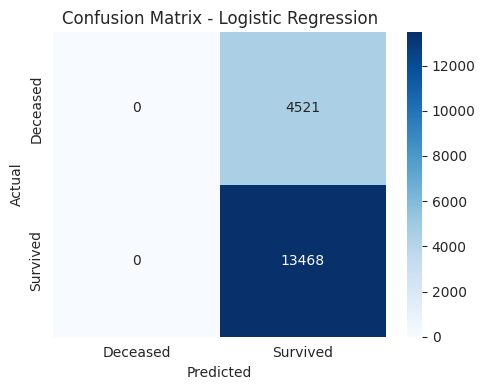

In [16]:

# 🧮 Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()


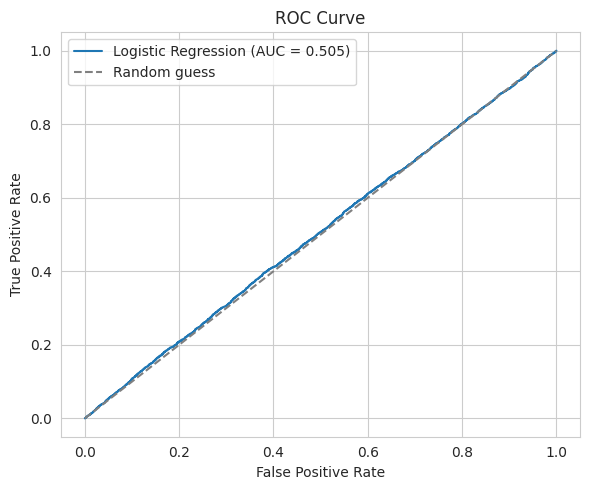

In [17]:

# 📉 ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


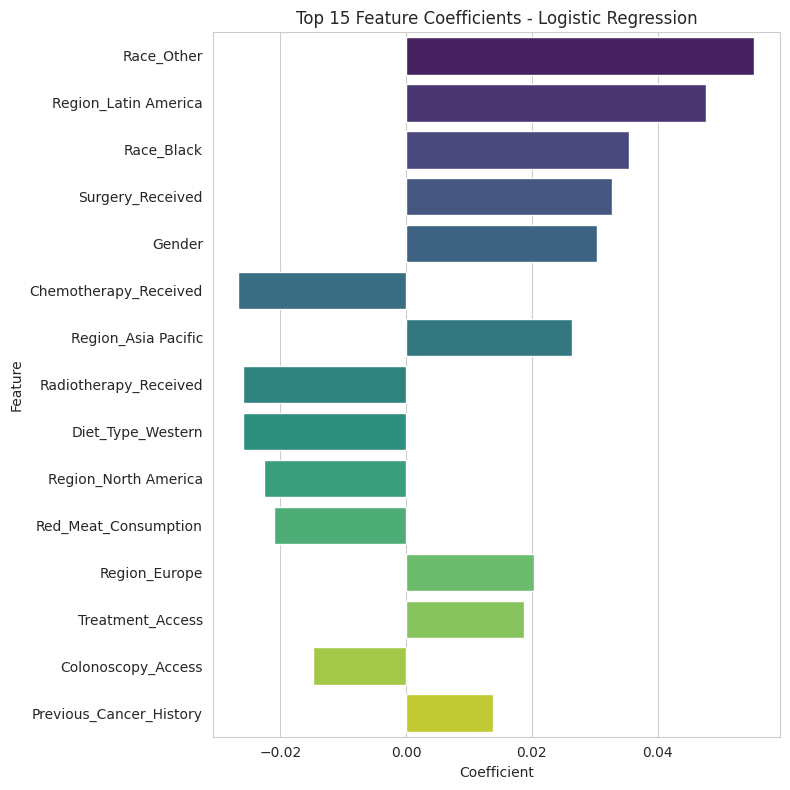

,Feature,Coefficient
27,Race_Other,0.055353
31,Region_Latin America,0.047620
25,Race_Black,0.035441
21,Surgery_Received,0.032743
1,Gender,0.030294
19,Chemotherapy_Received,-0.026672
29,Region_Asia Pacific,0.026366
20,Radiotherapy_Received,-0.026025
34,Diet_Type_Western,-0.025977
32,Region_North America,-0.022617


In [18]:

# 🔬 Feature importance via Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', hue='Feature',
            palette='viridis', legend=False)
plt.title('Top 15 Feature Coefficients - Logistic Regression')
plt.tight_layout()
plt.show()

coef_df.head(15)


## 🌳 Model Comparison
As an additional check, train a **Random Forest** classifier, which can capture non-linear relationships, and compare its performance to Logistic Regression.

In [19]:

# 🌳 Train a Random Forest model for comparison
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("📈 Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("📋 Classification Report:\n", classification_report(y_test, y_pred_rf, target_names=target_le.classes_))


✅ Random Forest Accuracy: 0.7486797487353383
📈 Random Forest ROC-AUC: 0.5055268102713357
📋 Classification Report:
               precision    recall  f1-score   support

    Deceased       0.00      0.00      0.00      4521
    Survived       0.75      1.00      0.86     13468

    accuracy                           0.75     17989
   macro avg       0.37      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


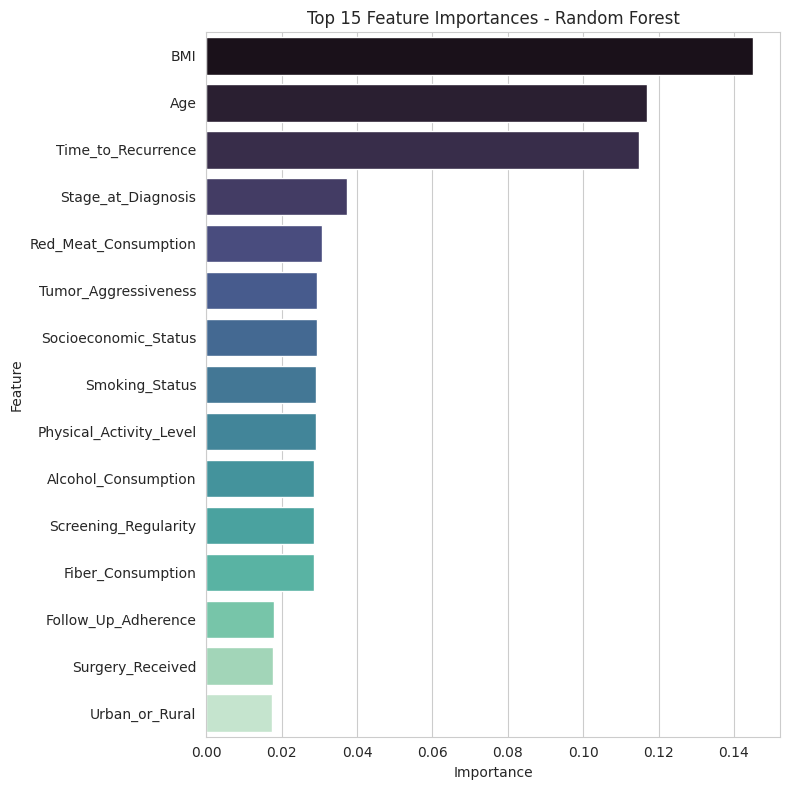

,Feature,Importance
10,BMI,0.144979
0,Age,0.116937
24,Time_to_Recurrence,0.114907
6,Stage_at_Diagnosis,0.037308
14,Red_Meat_Consumption,0.030702
7,Tumor_Aggressiveness,0.029513
3,Socioeconomic_Status,0.029305
12,Smoking_Status,0.029253
11,Physical_Activity_Level,0.029070
13,Alcohol_Consumption,0.028685


In [20]:

# 🌟 Random Forest feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', hue='Feature',
            palette='mako', legend=False)
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

importance_df.head(15)


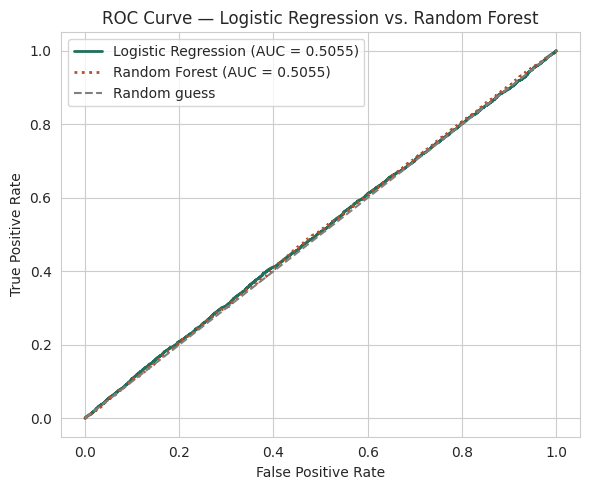

In [21]:

# 📉 ROC curve comparison — both models overlaid
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.4f})', color='#1F6F5C', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.4f})', color='#B5502D', linewidth=2, linestyle=':')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression vs. Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


## 🔄 Cross-Validation (Robustness Check)
A single train/test split can be lucky or unlucky — 5-fold cross-validation confirms whether the ~75% accuracy holds up consistently across different data splits.

In [22]:

# 🔄 5-fold stratified cross-validation for both models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                X_scaled, y, cv=cv, scoring='roc_auc')
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
                                X_scaled, y, cv=cv, scoring='roc_auc')

print(f"📊 Logistic Regression CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"📊 Random Forest CV ROC-AUC:       {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")


📊 Logistic Regression CV ROC-AUC: 0.5001 ± 0.0019
📊 Random Forest CV ROC-AUC:       0.5021 ± 0.0038


## 🏁 Model Performance Summary

In [23]:

# 🏁 Side-by-side summary of both models
baseline_acc = df['Survival_Status'].eq('Survived').mean()

summary_df = pd.DataFrame({
    'Model': ['Baseline (majority class)', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [baseline_acc, accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf)],
    'ROC-AUC': [0.5, roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_rf)],
    '5-Fold CV ROC-AUC (mean)': [np.nan, lr_cv_scores.mean(), rf_cv_scores.mean()]
})
summary_df


,Model,Accuracy,ROC-AUC,5-Fold CV ROC-AUC (mean)
0,Baseline (majority class),0.748691,0.500000,NaN
1,Logistic Regression,0.748680,0.505489,0.500115
2,Random Forest,0.748680,0.505527,0.502061


## ✅ Conclusion
- The dataset has 89,945 records and 30 columns with **no missing values**, so preprocessing focused on encoding categorical variables (ordinal mapping for ordered categories, one-hot encoding for nominal categories) and scaling numeric features.
- The target class is imbalanced: about 74.9% Survived vs 25.1% Deceased — this is the baseline accuracy any model must beat to be useful.
- 🧪 **Chi-Square and t-tests** on every feature confirm what the correlation table hinted at: none of the demographic, clinical, lifestyle, or treatment variables show a statistically significant relationship with `Survival_Status` in this dataset.
- 🤖 Both **Logistic Regression** and **Random Forest** landed at ~74.9% accuracy — identical to the majority-class baseline — with ROC-AUC around **0.50–0.51** in both the single train/test split and 5-fold cross-validation. That means neither model is doing better than random guessing once class imbalance is accounted for.
- 🔁 Even clinically intuitive relationships (Recurrence, Stage_at_Diagnosis, Tumor_Aggressiveness, Screening_Regularity) show survival rates hovering close to the overall average in every subgroup.
- **Key takeaway:** as provided, this dataset does not contain a learnable signal for `Survival_Status` using these features — the outcome appears to be generated independently of the recorded risk factors, treatment, and lifestyle variables (consistent with a synthetic/simulated dataset built without an embedded feature–outcome relationship). Any reported accuracy should be read alongside ROC-AUC and the baseline rate, never in isolation.
- 🚀 **Next steps** to move this project forward: (1) check the data source/generation process for an intended relationship, (2) engineer interaction features (e.g., Stage × Tumor_Aggressiveness), (3) try boosting models (XGBoost/Gradient Boosting) with hyperparameter tuning, and (4) apply SMOTE or class-weighting for imbalance if a real signal is later found.